In [ ]:
#@title 0) setup
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import itertools, random, time

# Reproducibility
SEED = 42
def resetRandom():
  torch.manual_seed(SEED)
  np.random.seed(SEED)
  random.seed(SEED)
resetRandom()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) MLP: A * B % C (A,B between 0..99, C between 0..19)

## 1.1) Dataset

In [ ]:
def one_hot(n, num_classes=100):
    # One-hot encode a single integer.
    v = np.zeros(num_classes, dtype=np.float32)
    v[n] = 1.0
    return v

# ── Generate all 190,000 input pairs ──
pairs = list(itertools.product(range(100), range(100), range(19)))
random.shuffle(pairs)

X_all, y_all = [], []
for a, b, c in pairs:
    x = np.concatenate([one_hot(a), one_hot(b), one_hot(c, 19)])   # 220-dim
    y = (a * b) % (c+1)
    X_all.append(x)
    y_all.append(y)

X_all = np.array(X_all)
y_all = np.array(y_all)

# 80-20 split
split = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

# DataLoaders — mini-batch (full-batch would be 8K samples)
BATCH_SIZE = 256
train_ds = TensorDataset(torch.tensor(X_train).to(device), torch.tensor(y_train, dtype=torch.long).to(device))
test_ds  = TensorDataset(torch.tensor(X_test).to(device),  torch.tensor(y_test, dtype=torch.long).to(device))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds):,} samples  |  Test: {len(test_ds):,} samples")
print(f"Input dim: {X_train.shape[1]}  |  Output classes: {len(np.unique(y_all))}")
print(f"Label distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")

Train: 152,000 samples  |  Test: 38,000 samples
Input dim: 219  |  Output classes: 19
Label distribution (train): {np.int64(0): np.int64(51411), np.int64(1): np.int64(11977), np.int64(2): np.int64(14363), np.int64(3): np.int64(10413), np.int64(4): np.int64(11615), np.int64(5): np.int64(6717), np.int64(6): np.int64(10053), np.int64(7): np.int64(4823), np.int64(8): np.int64(6869), np.int64(9): np.int64(4650), np.int64(10): np.int64(4769), np.int64(11): np.int64(2542), np.int64(12): np.int64(4452), np.int64(13): np.int64(1747), np.int64(14): np.int64(2023), np.int64(15): np.int64(1374), np.int64(16): np.int64(1254), np.int64(17): np.int64(538), np.int64(18): np.int64(410)}


## 1.2) DNN: 220->512->512->256->256->128 w/ ReLU / TanH

In [ ]:
class DNN(nn.Module):
    def __init__(self, input_dim=220, output_dim=19, useTanh=False):
        super().__init__()
        act = nn.Tanh if useTanh else nn.ReLU
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),  act(),
            nn.Linear(512, 512),        act(),
            nn.Linear(512, 256),        act(),
            nn.Linear(256, 256),        act(),
            nn.Linear(256, 128),        act(),
            nn.Linear(128, output_dim),
        )

    def forward(self, x):
        return self.net(x)

model = DNN().to(device)
print(model)

print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nPer-layer shapes:")
for name, param in model.named_parameters():
    if "weight" in name:
        print(f"  {name:30s}  {str(list(param.shape)):>15s}  ({param.numel():>6,} params)")


DNN(
  (net): Sequential(
    (0): Linear(in_features=220, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=20, bias=True)
  )
)

Total parameters: 608,404

Per-layer shapes:
  net.0.weight                         [512, 220]  (112,640 params)
  net.2.weight                         [512, 512]  (262,144 params)
  net.4.weight                         [256, 512]  (131,072 params)
  net.6.weight                         [256, 256]  (65,536 params)
  net.8.weight                         [128, 256]  (32,768 params)
  net.10.weight                         [20, 128]  ( 2,560 params)


## 1.3) Train

With 5 hidden layers and 7K samples A*B % 13 is much harder than A+B % 5.

In [ ]:
# ── Hyperparameters ──
LR = 1e-3
WEIGHT_DECAY = 0.1
MAX_EPOCHS = 100

all_runs = []  # global: stores {"name", "converged_epoch", "history"} per run

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            total_loss += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += len(yb)
    return total_loss / total, correct / total

def init_weights(m, method):
    if isinstance(m, nn.Linear):
        if method == "uniform":
            nn.init.uniform_(m.weight, -1, 1)
        elif method == "he":
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        elif method == "xavier":
            nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def train(input_dim=219, output_dim=19, useTanh=False, init="default", run_name="default"):
    # Reset model and optimizer
    global model, optimizer, criterion, history
    resetRandom()
    model = DNN(input_dim, output_dim, useTanh=useTanh).to(device)
    if init != "default":
        model.apply(lambda m: init_weights(m, init))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    # Reset logging
    history = {
        "epoch": [], "train_loss": [], "test_loss": [],
        "train_acc": [], "test_acc": []
    }

    print(f"\n{'='*60}")
    print(f"  🚀 Run: {run_name}")
    print(f"  Init: {init} | Activation: {'Tanh' if useTanh else 'ReLU'}")
    print(f"{'='*60}\n")

    # ── Training loop ──
    reached_100 = False

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_loss, train_acc = evaluate(train_loader)
        test_loss, test_acc   = evaluate(test_loader)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)

        print(f"Epoch {epoch:>6d} | "
              f"Train loss {train_loss:.4f}  acc {train_acc:.1%} | "
              f"Test loss {test_loss:.4f}  acc {test_acc:.1%}")

        if test_acc == 1.00 and train_acc == 1.00:
            print(f"\n{'='*60}")
            print(f"  ✅ 100% test accuracy reached at epoch {epoch}!")
            print(f"  📊 Final — Train: {train_acc:.2%}  Test: {test_acc:.2%}")
            print(f"{'='*60}")
            reached_100 = True
            break

    if not reached_100:
        print(f"\n⚠️  Did not reach 100% in {MAX_EPOCHS} epochs.")
        print(f"    Final test acc: {history['test_acc'][-1]:.1%}")

    converged_epoch = epoch if reached_100 else None
    all_runs.append({"name": run_name, "converged_epoch": converged_epoch, "history": dict(history)})


# 2) Uniform distribution [-1, 1] + ReLU:  won't converge

In [ ]:
train(init="uniform", run_name="Uniform+ReLU", useTanh=False, )


  🚀 Run: Uniform+ReLU
  Init: uniform | Activation: ReLU

Epoch      1 | Train loss 3.1566  acc 33.5% | Test loss 3.3206  acc 33.2%
Epoch      2 | Train loss 2.5260  acc 33.7% | Test loss 2.6261  acc 33.5%
Epoch      3 | Train loss 2.4086  acc 33.8% | Test loss 2.4742  acc 33.5%
Epoch      4 | Train loss 2.3759  acc 33.8% | Test loss 2.4199  acc 33.6%
Epoch      5 | Train loss 2.3635  acc 33.8% | Test loss 2.3944  acc 33.6%
Epoch      6 | Train loss 2.3578  acc 33.8% | Test loss 2.3803  acc 33.6%
Epoch      7 | Train loss 2.3550  acc 33.8% | Test loss 2.3719  acc 33.6%
Epoch      8 | Train loss 2.3533  acc 33.8% | Test loss 2.3665  acc 33.6%
Epoch      9 | Train loss 2.3522  acc 33.8% | Test loss 2.3630  acc 33.6%
Epoch     10 | Train loss 2.3514  acc 33.8% | Test loss 2.3605  acc 33.6%
Epoch     11 | Train loss 2.3494  acc 33.8% | Test loss 2.3581  acc 33.6%
Epoch     12 | Train loss 2.2965  acc 33.8% | Test loss 2.3067  acc 33.6%
Epoch     13 | Train loss 2.2451  acc 33.8% | Test lo

# 3) He/Kaiming + ReLU - converges!


In [ ]:
train(init="he", run_name="He+ReLU", useTanh=False )


  🚀 Run: He+ReLU
  Init: he | Activation: ReLU

Epoch      1 | Train loss 1.0759  acc 54.9% | Test loss 1.0956  acc 53.4%
Epoch      2 | Train loss 1.0284  acc 55.7% | Test loss 1.0499  acc 53.5%
Epoch      3 | Train loss 0.9939  acc 59.0% | Test loss 1.0221  acc 56.4%
Epoch      4 | Train loss 0.9040  acc 62.5% | Test loss 0.9322  acc 59.4%
Epoch      5 | Train loss 0.8591  acc 65.7% | Test loss 0.8907  acc 62.9%
Epoch      6 | Train loss 0.7594  acc 70.4% | Test loss 0.7917  acc 67.4%
Epoch      7 | Train loss 0.6438  acc 76.6% | Test loss 0.6797  acc 74.2%
Epoch      8 | Train loss 0.5254  acc 82.0% | Test loss 0.5497  acc 80.6%
Epoch      9 | Train loss 0.4820  acc 83.3% | Test loss 0.5057  acc 82.2%
Epoch     10 | Train loss 0.4555  acc 84.2% | Test loss 0.4788  acc 83.1%
Epoch     11 | Train loss 0.4109  acc 85.7% | Test loss 0.4370  acc 84.2%
Epoch     12 | Train loss 0.3575  acc 87.7% | Test loss 0.3845  acc 86.3%
Epoch     13 | Train loss 0.3021  acc 89.5% | Test loss 0.3330 

# 4) Xavier + Tanh - converges but slowly

In [ ]:
# Exercise: code up Xavier+Tanh

In [ ]:
#@title Answer
train(init="xavier", useTanh=True, run_name="Xavier+Tanh")


  🚀 Run: Xavier+Tanh
  Init: xavier | Activation: Tanh

Epoch      1 | Train loss 1.1263  acc 53.8% | Test loss 1.1320  acc 53.3%
Epoch      2 | Train loss 1.0507  acc 54.2% | Test loss 1.0558  acc 53.7%
Epoch      3 | Train loss 1.0262  acc 54.7% | Test loss 1.0303  acc 54.2%
Epoch      4 | Train loss 1.0237  acc 54.8% | Test loss 1.0274  acc 54.2%
Epoch      5 | Train loss 1.0162  acc 55.6% | Test loss 1.0211  acc 54.9%
Epoch      6 | Train loss 1.0054  acc 56.7% | Test loss 1.0095  acc 56.1%
Epoch      7 | Train loss 0.9715  acc 59.1% | Test loss 0.9754  acc 58.7%
Epoch      8 | Train loss 0.9168  acc 60.9% | Test loss 0.9220  acc 60.4%
Epoch      9 | Train loss 0.9121  acc 60.9% | Test loss 0.9157  acc 60.4%
Epoch     10 | Train loss 0.9054  acc 60.9% | Test loss 0.9081  acc 60.5%
Epoch     11 | Train loss 0.9062  acc 60.9% | Test loss 0.9092  acc 60.7%
Epoch     12 | Train loss 0.9043  acc 60.9% | Test loss 0.9068  acc 60.8%
Epoch     13 | Train loss 0.9077  acc 60.8% | Test loss

# 5) Xavier + ReLU: converges slower than He+ReLU

In [ ]:
# Exercise: code up Xavier+ReLU

In [ ]:
#@title Answer
train(init="xavier", run_name="Xavier+ReLU", useTanh=False)


  🚀 Run: Xavier+ReLU
  Init: xavier | Activation: ReLU

Epoch      1 | Train loss 1.0558  acc 54.7% | Test loss 1.0649  acc 54.2%
Epoch      2 | Train loss 1.0303  acc 55.0% | Test loss 1.0381  acc 54.3%
Epoch      3 | Train loss 0.9978  acc 57.7% | Test loss 1.0092  acc 56.5%
Epoch      4 | Train loss 0.8097  acc 65.5% | Test loss 0.8181  acc 64.7%
Epoch      5 | Train loss 0.7930  acc 66.3% | Test loss 0.8010  acc 65.5%
Epoch      6 | Train loss 0.7529  acc 67.8% | Test loss 0.7632  acc 66.9%
Epoch      7 | Train loss 0.7021  acc 70.3% | Test loss 0.7105  acc 69.8%
Epoch      8 | Train loss 0.5654  acc 76.9% | Test loss 0.5753  acc 76.0%
Epoch      9 | Train loss 0.5459  acc 77.4% | Test loss 0.5534  acc 76.7%
Epoch     10 | Train loss 0.4703  acc 81.3% | Test loss 0.4858  acc 80.2%
Epoch     11 | Train loss 0.3522  acc 87.6% | Test loss 0.3641  acc 86.9%
Epoch     12 | Train loss 0.3069  acc 89.6% | Test loss 0.3156  acc 89.1%
Epoch     13 | Train loss 0.2669  acc 90.9% | Test loss

# 6) Comparison Across Runs

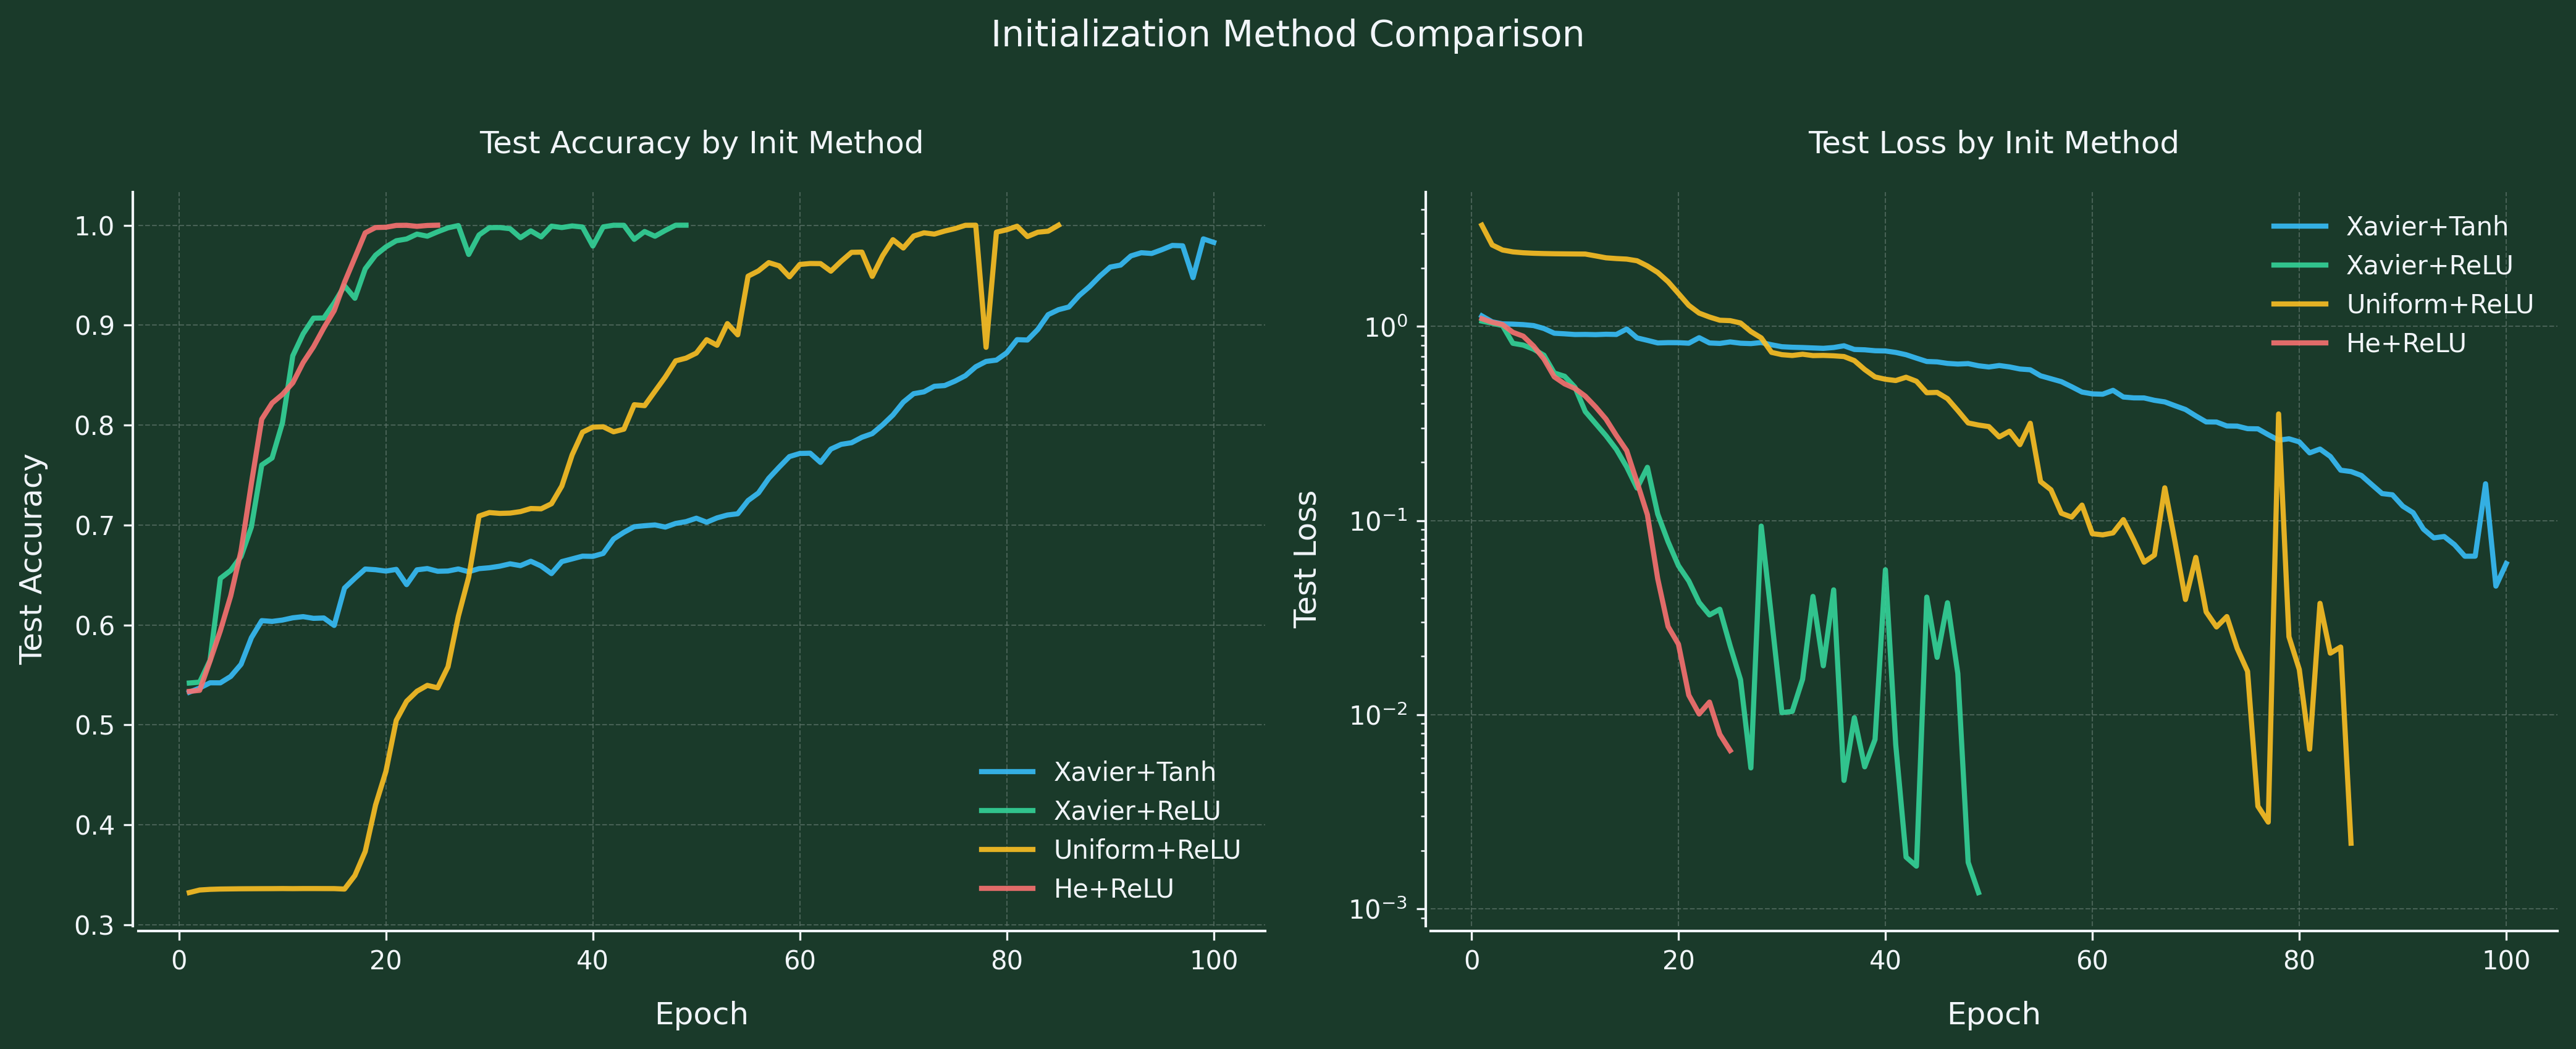


Run                  Converged Epoch     
----------------------------------------
He+ReLU              25                  
Xavier+ReLU          49                  
Uniform+ReLU         85                  
Xavier+Tanh          Did not converge    


In [ ]:
#@title Visualize
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import logging

# Suppress missing font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Prefer the deployment font when available, otherwise fall back to common sans-serif fonts
font_candidates = ['Inter', 'DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['font.family'] = font_candidates
font_path = 'fonts/Inter-Regular.ttf'
try:
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
except Exception:
    pass

# Set styling for all text and lines
plt.rcParams['text.color'] = '#F1F5F9'
plt.rcParams['axes.labelcolor'] = '#F1F5F9'
plt.rcParams['xtick.color'] = '#F1F5F9'
plt.rcParams['ytick.color'] = '#F1F5F9'
plt.rcParams['axes.edgecolor'] = '#F1F5F9'

# Grid styling
plt.rcParams['grid.color'] = '#5B7268'
plt.rcParams['grid.alpha'] = 0.7

def _coplot_luminance_from_rgba(rgba):
    r, g, b = mcolors.to_rgb(rgba)
    def _linear(c):
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    return 0.2126 * _linear(r) + 0.7152 * _linear(g) + 0.0722 * _linear(b)

def _coplot_text_color_for_rgba(rgba, preferred='#F1F5F9'):
    try:
        preferred_l = _coplot_luminance_from_rgba(mcolors.to_rgba(preferred))
        bg_l = _coplot_luminance_from_rgba(rgba)
        lighter = max(preferred_l, bg_l)
        darker = min(preferred_l, bg_l)
        ratio = (lighter + 0.05) / (darker + 0.05)
        if ratio >= 4.5:
            return preferred
    except Exception:
        pass
    bg_l = _coplot_luminance_from_rgba(rgba)
    return '#111111' if bg_l > 0.5 else '#FFFFFF'

# Create figure and axis with publication-quality settings
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=300)
fig.patch.set_facecolor('#1A3A2A')

# Distinct bright colors for dark background (modified to keep runs distinguishable)
colors = ["#38BDF8", "#34D399", "#FBBF24", "#F87171", "#A78BFA"]
line_styles = ["-","--",":","-."]
marker_styles = ["o","s","^","D"]

for idx, run in enumerate(all_runs):
    h = run["history"]

    line_style = line_styles[idx % len(line_styles)] if False else '-'
    marker_style = marker_styles[idx % len(marker_styles)] if False else ''

    # Plot accuracy
    axes[0].plot(h["epoch"], h["test_acc"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2,
                 linestyle=line_style, marker=marker_style, alpha=0.9)

    # Plot loss
    axes[1].plot(h["epoch"], h["test_loss"], label=run["name"],
                 color=colors[idx % len(colors)], linewidth=2,
                 linestyle=line_style, marker=marker_style, alpha=0.9)

# Apply custom styling to both axes
for ax in axes:
    ax.set_facecolor('#1A3A2A')
    ax.set_xlabel('Epoch', fontsize=12, labelpad=10, color='#F1F5F9')

    # Add grid
    ax.grid(axis='both', alpha=0.7, color='#5B7268', linestyle='--', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_color('#F1F5F9')
    ax.spines['left'].set_color('#F1F5F9')

    # Adjust spine positions
    ax.spines['left'].set_position(('outward', 2))
    ax.spines['bottom'].set_position(('outward', 2))

    # Add legend
    ax.legend(frameon=False, fontsize=10)

# Specific titles and labels
axes[0].set_ylabel('Test Accuracy', fontsize=12, color='#F1F5F9', labelpad=10)
axes[0].set_title('Test Accuracy by Init Method', color='#F1F5F9', pad=15)

axes[1].set_ylabel('Test Loss', fontsize=12, color='#F1F5F9', labelpad=10)
axes[1].set_title('Test Loss by Init Method', color='#F1F5F9', pad=15)
axes[1].set_yscale('log')

# Global title
plt.suptitle("Initialization Method Comparison", fontsize=14, y=1.02, color='#F1F5F9')

# Tight layout
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Run':<20s} {'Converged Epoch':<20s}")
print("-" * 40)
for run in sorted(all_runs, key=lambda x: (x['converged_epoch'] is None, x['converged_epoch'])):
    ep = run["converged_epoch"]
    print(f"{run['name']:<20s} {str(ep) if ep else 'Did not converge':<20s}")
